
# Level 3 — Benchmark Minimax và Alpha-Beta cho game Caro



Nội dung đáp ứng các yêu cầu Level 3:

1. Thiết kế tối thiểu 5 trạng thái bàn cờ kiểm thử.
2. Chạy Minimax và Alpha-Beta trên cùng trạng thái.
3. Dùng cùng độ sâu tìm kiếm và cùng hàm đánh giá khi so sánh.
4. Thử nhiều độ sâu: `1, 2, 3, 4, 5, 6, 7, 8`.
5. Lưu kết quả theo bảng, gồm: nước đi chọn, điểm đánh giá, số node đã xét, số lần cắt tỉa, thời gian chạy.
6. Sinh biểu đồ và gợi ý nhận xét để đưa vào báo cáo.

> Quy ước theo file `AI.py`: AI/O = `1`, Human/X = `-1`, ô trống = `0`, bàn cờ kích thước `9 x 9`, thắng khi có 4 quân liên tiếp.



## 1. Import thư viện và nạp class AI



In [2]:

import os
import sys
import math
import time
import copy
import importlib.util
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def load_ai_module():
    """Tìm và nạp file AI.py của project."""
    candidates = [
        Path("AI.py"),
        Path("../AI.py"),
        Path("../src/AI.py"),
        Path("/mnt/data/AI(1).py"),
    ]
    for path in candidates:
        if path.exists():
            spec = importlib.util.spec_from_file_location("AI_module", path)
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            print(f"Loaded AI module from: {path.resolve()}")
            return module
    raise FileNotFoundError(
        "Không tìm thấy AI.py. Hãy đặt notebook cùng thư mục với AI.py hoặc sửa biến candidates."
    )

AI_module = load_ai_module()
AiTicTacToe = AI_module.AiTicTacToe
N = AI_module.N
SCORES = AI_module.SCORES

print("Board size:", N, "x", N)
print("Scores:", SCORES)


Loaded AI module from: D:\2 - (25 - 26)\CSAI\Tictactoe\AI.py
Board size: 9 x 9
Scores: {'FOUR': 1000000, 'OPEN_THREE': 220000, 'BLOCK_THREE': 55000, 'OPEN_TWO': 4500, 'BLOCK_TWO': 500, 'OPEN_ONE': 8, 'BLOCK_ONE': 1, 'DOUBLE_OPEN_THREE': 850000, 'OPEN_THREE_AND_OPEN_TWO': 420000, 'DOUBLE_OPEN_TWO': 95000, 'TWO_BLOCK_THREES': 120000}



## 2. Tạo phiên bản AI có đếm số trạng thái/node

viết lại hai hàm tìm kiếm có bộ đếm:

- `minimax_counted()`
- `alphabeta_counted()`



In [3]:
class SearchLimitReached(Exception):

    def __init__(self, reason):
        super().__init__(reason)
        self.reason = reason

class BenchmarkAI(AiTicTacToe):

    def reset_stats(self):
        self.nodes = 0
        self.cutoffs = 0
        self.start_time = None
        self.max_seconds = None
        self.max_nodes = None

    def check_limits(self):
        if self.max_nodes is not None and self.nodes >= self.max_nodes:
            raise SearchLimitReached("node_limit")
        if self.max_seconds is not None and self.start_time is not None:
            if time.perf_counter() - self.start_time >= self.max_seconds:
                raise SearchLimitReached("time_limit")

    def terminal_or_eval(self, depth, bound):

        if self.lastPlayed != 0 and self.isWin(self.currentI, self.currentJ, self.lastPlayed):
            if self.lastPlayed == 1:      # AI thắng
                return SCORES["FOUR"] + depth * 200
            else:                         # Human thắng
                return -SCORES["FOUR"] - depth * 200

        if self.emptyCells <= 0:
            return 0

        if depth <= 0 or not bound:
            return self.evaluate()

        return None

    def minimax_counted(self, depth, bound, isMaximizing):
        self.nodes += 1
        if self.nodes % 2048 == 0:
            self.check_limits()

        terminal_score = self.terminal_or_eval(depth, bound)
        if terminal_score is not None:
            return terminal_score

        state = 1 if isMaximizing else -1
        best_score = -math.inf if isMaximizing else math.inf

        for i, j in self.orderedMoves(bound, depth):
            saved = (self.currentI, self.currentJ, self.lastPlayed)

            self._place(i, j, state)
            self.currentI, self.currentJ, self.lastPlayed = i, j, state

            new_bound = bound - {(i, j)}
            self.update_bound(i, j, new_bound, radius=1)

            score = self.minimax_counted(depth - 1, new_bound, not isMaximizing)

            self._unplace(i, j, state)
            self.currentI, self.currentJ, self.lastPlayed = saved

            if isMaximizing:
                best_score = max(best_score, score)
            else:
                best_score = min(best_score, score)

        return best_score

    def alphabeta_counted(self, depth, bound, alpha, beta, isMaximizing):
        self.nodes += 1
        if self.nodes % 2048 == 0:
            self.check_limits()

        terminal_score = self.terminal_or_eval(depth, bound)
        if terminal_score is not None:
            return terminal_score

        state = 1 if isMaximizing else -1

        if isMaximizing:
            best_score = -math.inf
            for i, j in self.orderedMoves(bound, depth):
                saved = (self.currentI, self.currentJ, self.lastPlayed)

                self._place(i, j, state)
                self.currentI, self.currentJ, self.lastPlayed = i, j, state

                new_bound = bound - {(i, j)}
                self.update_bound(i, j, new_bound, radius=1)

                score = self.alphabeta_counted(depth - 1, new_bound, alpha, beta, False)

                self._unplace(i, j, state)
                self.currentI, self.currentJ, self.lastPlayed = saved

                best_score = max(best_score, score)
                alpha = max(alpha, best_score)

                if alpha >= beta:
                    self.cutoffs += 1
                    break

            return best_score

        else:
            best_score = math.inf
            for i, j in self.orderedMoves(bound, depth):
                saved = (self.currentI, self.currentJ, self.lastPlayed)

                self._place(i, j, state)
                self.currentI, self.currentJ, self.lastPlayed = i, j, state

                new_bound = bound - {(i, j)}
                self.update_bound(i, j, new_bound, radius=1)

                score = self.alphabeta_counted(depth - 1, new_bound, alpha, beta, True)

                self._unplace(i, j, state)
                self.currentI, self.currentJ, self.lastPlayed = saved

                best_score = min(best_score, score)
                beta = min(beta, best_score)

                if beta <= alpha:
                    self.cutoffs += 1
                    break

            return best_score

    def prepare_bound(self):

        self.sync_state()
        bound = set(self.next_bound)

        if not bound:
            for i in range(N):
                for j in range(N):
                    if self.board[i][j] != 0:
                        self.update_bound(i, j, bound, radius=1)

        if not bound:
            bound = {(N // 2, N // 2)}

        return bound

    def best_move_counted(self, algorithm, depth, max_seconds=None, max_nodes=None):

        self.depth = depth
        self.reset_stats()
        self.max_seconds = max_seconds
        self.max_nodes = max_nodes
        self.sync_state()
        self.eval_cache.clear()

        bound = self.prepare_bound()
        best_score = -math.inf
        best_move = (-1, -1)
        status = "ok"

        self.start_time = time.perf_counter()

        try:
            # AI luôn là bên Maximizing và đánh quân 1
            for i, j in self.orderedMoves(bound, depth):
                self.check_limits()
                saved = (self.currentI, self.currentJ, self.lastPlayed)

                self._place(i, j, 1)
                self.currentI, self.currentJ, self.lastPlayed = i, j, 1

                new_bound = bound - {(i, j)}
                self.update_bound(i, j, new_bound, radius=1)

                if algorithm == "Minimax":
                    score = self.minimax_counted(depth - 1, new_bound, False)
                elif algorithm == "Alpha-Beta":
                    score = self.alphabeta_counted(depth - 1, new_bound, -math.inf, math.inf, False)
                else:
                    raise ValueError("algorithm phải là 'Minimax' hoặc 'Alpha-Beta'")

                self._unplace(i, j, 1)
                self.currentI, self.currentJ, self.lastPlayed = saved

                if score > best_score:
                    best_score = score
                    best_move = (i, j)

        except SearchLimitReached as e:
            status = e.reason

        elapsed_s = (time.perf_counter() - self.start_time)

        return {
            "best_move": best_move,
            "score": best_score,
            "nodes": self.nodes,
            "cutoffs": self.cutoffs,
            "time_s": elapsed_s,
            "status": status,
        }



## 3. Thiết kế các trạng thái thử nghiệm

Notebook dùng 7 trạng thái.

1. **Đầu ván rỗng** — kiểm tra nước mở đầu.
2. **Đầu ván đã có vài quân** — AI bắt đầu phải lựa chọn theo thế cờ.
3. **Giữa ván** — có nhiều quân và nhiều hướng phát triển.
4. **AI có thể thắng ngay** — kiểm tra khả năng tìm nước kết thúc.
5. **Người chơi sắp thắng, AI cần chặn** — kiểm tra khả năng phòng thủ.
6. **Hai bên đều có cơ hội tấn công** — kiểm tra cân bằng công/thủ.
7. **Nhiều nhánh hợp lệ** — kiểm tra chi phí tìm kiếm khi vùng ứng viên rộng.


In [4]:

def make_board(moves):
    """moves: list[(row, col, value)], value: 1 = AI/O, -1 = Human/X"""
    board = [[0 for _ in range(N)] for _ in range(N)]
    for row, col, value in moves:
        board[row][col] = value
    return board


def board_to_dataframe(board):
    """Hiển thị bàn cờ: O = AI, X = Human, . = trống."""
    symbol = {1: "O", -1: "X", 0: "."}
    return pd.DataFrame([[symbol[cell] for cell in row] for row in board])


TEST_STATES = [
    {
        "name": "S1_Empty_Board",
        "description": "Trạng thái đầu ván: bàn cờ rỗng.",
        "board": make_board([]),
    },
    {
        "name": "S2_Opening",
        "description": "Đầu ván có vài quân quanh trung tâm.",
        "board": make_board([
            (4, 4, -1),
            (4, 5, 1),
            (3, 4, -1),
        ]),
    },
    {
        "name": "S3_Mid_Game",
        "description": "Giữa ván: hai bên đã có nhiều quân và nhiều hướng phát triển.",
        "board": make_board([
            (4, 4, -1), (4, 5, 1), (3, 4, -1), (5, 4, 1),
            (3, 3, -1), (5, 5, 1), (2, 4, -1), (6, 4, 1),
            (4, 3, -1), (4, 6, 1),
        ]),
    },
    {
        "name": "S4_AI_Win_Now",
        "description": "AI có 3 quân liên tiếp và có thể thắng ngay bằng quân thứ 4.",
        "board": make_board([
            (4, 2, 1), (4, 3, 1), (4, 4, 1),
            (2, 2, -1), (3, 3, -1), (6, 6, -1),
        ]),
    },
    {
        "name": "S5_Block_Human",
        "description": "Người chơi có 3 quân liên tiếp, AI cần chặn ngay.",
        "board": make_board([
            (2, 2, -1), (2, 3, -1), (2, 4, -1),
            (5, 5, 1), (6, 6, 1), (4, 4, 1),
        ]),
    },
    {
        "name": "S6_Both_Attack",
        "description": "Hai bên đều có cơ hội tấn công, AI phải cân bằng giữa tạo thế và phòng thủ.",
        "board": make_board([
            (4, 4, 1), (4, 5, 1), (4, 6, 0),
            (3, 3, -1), (2, 2, -1),
            (5, 4, -1), (6, 4, 1),
            (5, 5, -1), (3, 5, 1),
        ]),
    },
    {
        "name": "S7_Many_Branches",
        "description": "Các quân nằm phân tán, tạo nhiều nước đi hợp lệ trong vùng bound.",
        "board": make_board([
            (1, 1, -1), (1, 7, 1),
            (7, 1, -1), (7, 7, 1),
            (4, 4, -1), (3, 6, 1),
        ]),
    },
]

print(f"Số trạng thái kiểm thử: {len(TEST_STATES)}")
for state in TEST_STATES:
    print("-", state["name"], ":", state["description"])


Số trạng thái kiểm thử: 7
- S1_Empty_Board : Trạng thái đầu ván: bàn cờ rỗng.
- S2_Opening : Đầu ván có vài quân quanh trung tâm.
- S3_Mid_Game : Giữa ván: hai bên đã có nhiều quân và nhiều hướng phát triển.
- S4_AI_Win_Now : AI có 3 quân liên tiếp và có thể thắng ngay bằng quân thứ 4.
- S5_Block_Human : Người chơi có 3 quân liên tiếp, AI cần chặn ngay.
- S6_Both_Attack : Hai bên đều có cơ hội tấn công, AI phải cân bằng giữa tạo thế và phòng thủ.
- S7_Many_Branches : Các quân nằm phân tán, tạo nhiều nước đi hợp lệ trong vùng bound.



### Xem nhanh một trạng thái bàn cờ




In [5]:

state_index = 4  # đổi từ 0 đến len(TEST_STATES)-1
print(TEST_STATES[state_index]["name"])
print(TEST_STATES[state_index]["description"])
board_to_dataframe(TEST_STATES[state_index]["board"])


S5_Block_Human
Người chơi có 3 quân liên tiếp, AI cần chặn ngay.


,0,1,2,3,4,5,6,7,8
0,.,.,.,.,.,.,.,.,.
1,.,.,.,.,.,.,.,.,.
2,.,.,X,X,X,.,.,.,.
3,.,.,.,.,.,.,.,.,.
4,.,.,.,.,O,.,.,.,.
5,.,.,.,.,.,O,.,.,.
6,.,.,.,.,.,.,O,.,.
7,.,.,.,.,.,.,.,.,.
8,.,.,.,.,.,.,.,.,.


## 4. Chạy benchmark

Độ sâu từ `1` đến `8`.

- `MAX_SECONDS_PER_RUN`: giới hạn thời gian cho mỗi lần chạy.
- `MAX_NODES_PER_RUN`: giới hạn số node cho mỗi lần chạy.
- cột `status`: `ok`, `time_limit`, hoặc `node_limit`.



In [6]:
DEPTHS = list(range(1, 9))
ALGORITHMS = ["Minimax", "Alpha-Beta"]

# Giới hạn an toàn cho mỗi lần chạy.
# Tăng nếu máy bạn mạnh; đặt None nếu muốn chạy full nhưng có thể rất lâu ở depth 7–8.
MAX_SECONDS_PER_RUN = None
MAX_NODES_PER_RUN = 2_000_000


def run_one_benchmark(board, algorithm, depth):
    ai = BenchmarkAI(depth=depth)
    ai.board = copy.deepcopy(board)
    ai.sync_state()
    return ai.best_move_counted(
        algorithm=algorithm,
        depth=depth,
        max_seconds=MAX_SECONDS_PER_RUN,
        max_nodes=MAX_NODES_PER_RUN,
    )


def run_all_benchmarks(test_states, depths, algorithms):
    rows = []
    total = len(test_states) * len(depths) * len(algorithms)
    done = 0

    for state in test_states:
        for depth in depths:
            for algorithm in algorithms:
                done += 1
                print(f"[{done}/{total}] {state['name']} | depth={depth} | {algorithm}")

                result = run_one_benchmark(state["board"], algorithm, depth)

                rows.append({
                    "state": state["name"],
                    "description": state["description"],
                    "depth": depth,
                    "algorithm": algorithm,
                    "best_move": result["best_move"],
                    "score": result["score"],
                    "nodes": result["nodes"],
                    "cutoffs": result["cutoffs"],
                    "time_s": result["time_s"],
                    "status": result["status"],
                })

    return pd.DataFrame(rows)

results_df = run_all_benchmarks(TEST_STATES, DEPTHS, ALGORITHMS)
results_df


[1/112] S1_Empty_Board | depth=1 | Minimax
[2/112] S1_Empty_Board | depth=1 | Alpha-Beta
[3/112] S1_Empty_Board | depth=2 | Minimax
[4/112] S1_Empty_Board | depth=2 | Alpha-Beta
[5/112] S1_Empty_Board | depth=3 | Minimax
[6/112] S1_Empty_Board | depth=3 | Alpha-Beta
[7/112] S1_Empty_Board | depth=4 | Minimax
[8/112] S1_Empty_Board | depth=4 | Alpha-Beta
[9/112] S1_Empty_Board | depth=5 | Minimax
[10/112] S1_Empty_Board | depth=5 | Alpha-Beta
[11/112] S1_Empty_Board | depth=6 | Minimax
[12/112] S1_Empty_Board | depth=6 | Alpha-Beta
[13/112] S1_Empty_Board | depth=7 | Minimax
[14/112] S1_Empty_Board | depth=7 | Alpha-Beta
[15/112] S1_Empty_Board | depth=8 | Minimax
[16/112] S1_Empty_Board | depth=8 | Alpha-Beta
[17/112] S2_Opening | depth=1 | Minimax
[18/112] S2_Opening | depth=1 | Alpha-Beta
[19/112] S2_Opening | depth=2 | Minimax
[20/112] S2_Opening | depth=2 | Alpha-Beta
[21/112] S2_Opening | depth=3 | Minimax
[22/112] S2_Opening | depth=3 | Alpha-Beta
[23/112] S2_Opening | depth=4 | 

,state,description,depth,algorithm,best_move,score,nodes,cutoffs,time_s,status
0,S1_Empty_Board,Trạng thái đầu ván: bàn cờ rỗng.,1,Minimax,"(4, 4)",32.0,1,0,0.000087,ok
1,S1_Empty_Board,Trạng thái đầu ván: bàn cờ rỗng.,1,Alpha-Beta,"(4, 4)",32.0,1,0,0.000047,ok
2,S1_Empty_Board,Trạng thái đầu ván: bàn cờ rỗng.,2,Minimax,"(4, 4)",0.0,9,0,0.000379,ok
3,S1_Empty_Board,Trạng thái đầu ván: bàn cờ rỗng.,2,Alpha-Beta,"(4, 4)",0.0,9,0,0.000464,ok
4,S1_Empty_Board,Trạng thái đầu ván: bàn cờ rỗng.,3,Minimax,"(4, 4)",4516.0,97,0,0.003539,ok
...,...,...,...,...,...,...,...,...,...,...
107,S7_Many_Branches,"Các quân nằm phân tán, tạo nhiều nước đi hợp l...",6,Alpha-Beta,"(2, 7)",1000200.0,27437,4541,2.760971,ok
108,S7_Many_Branches,"Các quân nằm phân tán, tạo nhiều nước đi hợp l...",7,Minimax,"(-1, -1)",-inf,2000896,0,73.064644,node_limit
109,S7_Many_Branches,"Các quân nằm phân tán, tạo nhiều nước đi hợp l...",7,Alpha-Beta,"(2, 7)",1000400.0,47617,10641,21.801013,ok
110,S7_Many_Branches,"Các quân nằm phân tán, tạo nhiều nước đi hợp l...",8,Minimax,"(-1, -1)",-inf,2000896,0,239.982638,node_limit



## 5. Bảng kết quả thực nghiệm

Các cột quan trọng:

- `nodes`: số trạng thái/node thuật toán đã xét.
- `time_s`: thời gian chạy tính bằng giây.
- `cutoffs`: số lần Alpha-Beta cắt tỉa nhánh. Minimax không cắt tỉa nên giá trị này bằng 0.
- `best_move`: nước đi AI chọn ở dạng `(row, col)`.


In [7]:
summary_df = results_df.copy()
summary_df["time_s"] = summary_df["time_s"].round(3)
summary_df = summary_df[[
    "state", "depth", "algorithm", "best_move", "score", "nodes", "cutoffs", "time_s", "status"
]]
summary_df


,state,depth,algorithm,best_move,score,nodes,cutoffs,time_s,status
0,S1_Empty_Board,1,Minimax,"(4, 4)",32.0,1,0,0.000,ok
1,S1_Empty_Board,1,Alpha-Beta,"(4, 4)",32.0,1,0,0.000,ok
2,S1_Empty_Board,2,Minimax,"(4, 4)",0.0,9,0,0.000,ok
3,S1_Empty_Board,2,Alpha-Beta,"(4, 4)",0.0,9,0,0.000,ok
4,S1_Empty_Board,3,Minimax,"(4, 4)",4516.0,97,0,0.004,ok
...,...,...,...,...,...,...,...,...,...
107,S7_Many_Branches,6,Alpha-Beta,"(2, 7)",1000200.0,27437,4541,2.761,ok
108,S7_Many_Branches,7,Minimax,"(-1, -1)",-inf,2000896,0,73.065,node_limit
109,S7_Many_Branches,7,Alpha-Beta,"(2, 7)",1000400.0,47617,10641,21.801,ok
110,S7_Many_Branches,8,Minimax,"(-1, -1)",-inf,2000896,0,239.983,node_limit


In [8]:

output_csv = "benchmark_results.csv"
summary_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"Đã lưu bảng kết quả vào: {output_csv}")


Đã lưu bảng kết quả vào: benchmark_results.csv



## 6. So sánh trực tiếp Minimax và Alpha-Beta

Ghép kết quả của hai thuật toán trên cùng trạng thái và cùng độ sâu để tính:

- Tỉ lệ giảm node của Alpha-Beta so với Minimax.
- Tỉ lệ giảm thời gian chạy.


In [9]:
compare_df = results_df.pivot_table(
    index=["state", "depth"],
    columns="algorithm",
    values=["nodes", "time_s"],
    aggfunc="first"
).reset_index()

# Làm phẳng tên cột
compare_df.columns = [
    "_".join([str(x) for x in col if x]) if isinstance(col, tuple) else col
    for col in compare_df.columns
]

compare_df["node_reduction_%"] = (
    (1 - compare_df["nodes_Alpha-Beta"] / compare_df["nodes_Minimax"]) * 100
).round(2)

compare_df["time_reduction_%"] = (
    (1 - compare_df["time_s_Alpha-Beta"] / compare_df["time_s_Minimax"]) * 100
).round(2)

compare_df["time_s_Minimax"] = compare_df["time_s_Minimax"].round(3)
compare_df["time_s_Alpha-Beta"] = compare_df["time_s_Alpha-Beta"].round(3)

status_df = results_df.pivot_table(
    index=["state", "depth"],
    columns="algorithm",
    values="status",
    aggfunc="first"
).reset_index()
status_df.columns = [
    f"status_{col}" if col in ALGORITHMS else col
    for col in status_df.columns
]
compare_df = compare_df.merge(status_df, on=["state", "depth"], how="left")

compare_df


,state,depth,nodes_Alpha-Beta,nodes_Minimax,time_s_Alpha-Beta,time_s_Minimax,node_reduction_%,time_reduction_%,status_Alpha-Beta,status_Minimax
0,S1_Empty_Board,1,1,1,0.000,0.000,0.00,45.86,ok,ok
1,S1_Empty_Board,2,9,9,0.000,0.000,0.00,-22.45,ok,ok
2,S1_Empty_Board,3,26,97,0.002,0.004,73.20,30.93,ok,ok
3,S1_Empty_Board,4,309,1297,0.052,0.074,76.18,29.97,ok,ok
4,S1_Empty_Board,5,1336,20577,0.253,2.034,93.51,87.54,ok,ok
5,S1_Empty_Board,6,7675,318533,1.332,25.626,97.59,94.80,ok,ok
6,S1_Empty_Board,7,14902,2000896,3.504,159.213,99.26,97.80,ok,node_limit
7,S1_Empty_Board,8,39520,2000896,11.713,157.030,98.02,92.54,ok,node_limit
8,S2_Opening,1,12,12,0.000,0.000,0.00,0.19,ok,ok
9,S2_Opening,2,186,186,0.022,0.011,0.00,-91.19,ok,ok



## 7. Biểu đồ phân tích


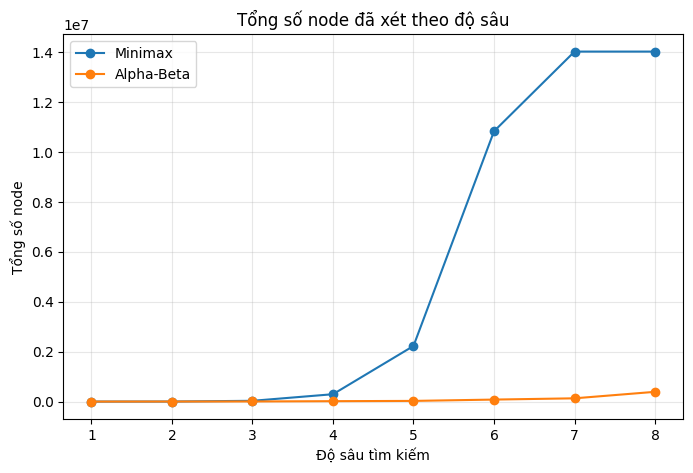

In [10]:

# Biểu đồ tổng số node theo độ sâu và thuật toán
nodes_by_depth = results_df.groupby(["depth", "algorithm"], as_index=False)["nodes"].sum()

plt.figure(figsize=(8, 5))
for algorithm in ALGORITHMS:
    data = nodes_by_depth[nodes_by_depth["algorithm"] == algorithm]
    plt.plot(data["depth"], data["nodes"], marker="o", label=algorithm)

plt.title("Tổng số node đã xét theo độ sâu")
plt.xlabel("Độ sâu tìm kiếm")
plt.ylabel("Tổng số node")
plt.xticks(DEPTHS)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


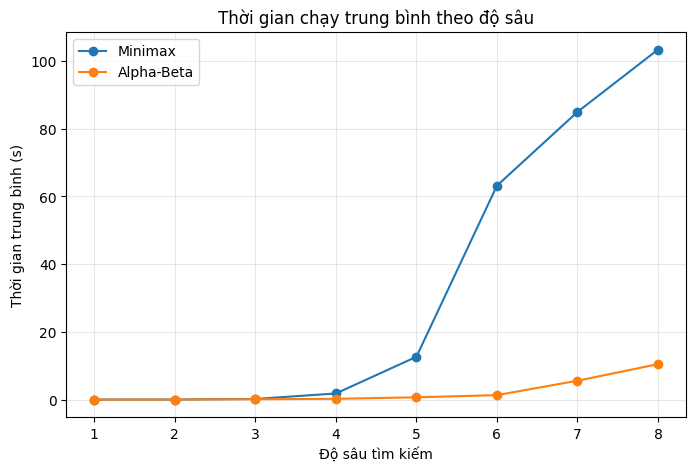

In [11]:

# Biểu đồ thời gian chạy trung bình theo độ sâu
avg_time_by_depth = results_df.groupby(["depth", "algorithm"], as_index=False)["time_s"].mean()

plt.figure(figsize=(8, 5))
for algorithm in ALGORITHMS:
    data = avg_time_by_depth[avg_time_by_depth["algorithm"] == algorithm]
    plt.plot(data["depth"], data["time_s"], marker="o", label=algorithm)

plt.title("Thời gian chạy trung bình theo độ sâu")
plt.xlabel("Độ sâu tìm kiếm")
plt.ylabel("Thời gian trung bình (s)")
plt.xticks(DEPTHS)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


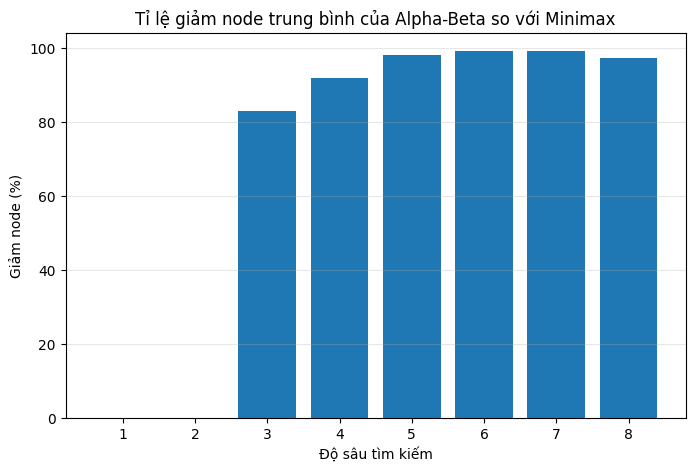

In [12]:

# Biểu đồ phần trăm giảm node của Alpha-Beta so với Minimax
avg_reduction = compare_df.groupby("depth", as_index=False)["node_reduction_%"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_reduction["depth"].astype(str), avg_reduction["node_reduction_%"])
plt.title("Tỉ lệ giảm node trung bình của Alpha-Beta so với Minimax")
plt.xlabel("Độ sâu tìm kiếm")
plt.ylabel("Giảm node (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()



## 8. Nhận xét tự động cho báo cáo



In [13]:
def make_report_comments(results_df, compare_df):
    total_states = results_df["state"].nunique()
    depths = sorted(results_df["depth"].unique())

    total_nodes = results_df.groupby("algorithm")["nodes"].sum()
    total_time = results_df.groupby("algorithm")["time_s"].sum()

    ok_compare = compare_df[
        (compare_df.get("status_Minimax", "ok") == "ok") &
        (compare_df.get("status_Alpha-Beta", "ok") == "ok")
    ].copy()
    if len(ok_compare) == 0:
        ok_compare = compare_df.copy()

    avg_node_reduction = ok_compare["node_reduction_%"].mean()
    avg_time_reduction = ok_compare["time_reduction_%"].mean()

    deepest = max(depths)
    deep_compare = compare_df[compare_df["depth"] == deepest]
    deep_node_reduction = deep_compare["node_reduction_%"].mean()
    deep_time_reduction = deep_compare["time_reduction_%"].mean()

    limit_rows = results_df[results_df["status"] != "ok"]
    if len(limit_rows) > 0:
        limit_note = (
            f"\n\nỞ các độ sâu lớn, có {len(limit_rows)} lượt chạy chạm giới hạn "
            f"thời gian/node. Vì vậy, các dòng có `status != ok` nên được xem là số liệu tham khảo "
            f"về độ nặng tính toán, không phải kết quả tìm kiếm đầy đủ."
        )
    else:
        limit_note = ""

    comments = f"""
### Nhận xét về thiết kế thực nghiệm

Thực nghiệm sử dụng {total_states} trạng thái bàn cờ khác nhau, bao gồm trạng thái đầu ván, giữa ván, trạng thái AI có thể thắng ngay, trạng thái người chơi sắp thắng cần chặn, trạng thái hai bên cùng có cơ hội tấn công và trạng thái có nhiều nhánh hợp lệ. Các trạng thái này giúp đánh giá thuật toán trong cả tình huống đơn giản, tình huống chiến thuật rõ ràng và tình huống có không gian tìm kiếm lớn.

### Nhận xét về số trạng thái đã xét

Tổng số node Minimax đã xét là {int(total_nodes.get('Minimax', 0)):,}, trong khi Alpha-Beta đã xét {int(total_nodes.get('Alpha-Beta', 0)):,} node. Với các lượt chạy hoàn thành đầy đủ, Alpha-Beta giảm trung bình khoảng {avg_node_reduction:.2f}% số node so với Minimax. Điều này cho thấy Alpha-Beta không thay đổi bản chất lựa chọn nước đi của Minimax, nhưng loại bỏ được nhiều nhánh không cần thiết nhờ điều kiện cắt tỉa alpha và beta.{limit_note}

### Nhận xét về thời gian chạy

Tổng thời gian chạy của Minimax là {total_time.get('Minimax', 0):.3f} s, còn Alpha-Beta là {total_time.get('Alpha-Beta', 0):.3f} s. Với các lượt chạy hoàn thành đầy đủ, Alpha-Beta giảm trung bình khoảng {avg_time_reduction:.2f}% thời gian chạy. Mức giảm thời gian có thể không hoàn toàn tỉ lệ với mức giảm node vì còn phụ thuộc vào chi phí sắp xếp nước đi, cập nhật bound, kiểm tra thắng và gọi hàm đánh giá.

### Nhận xét về ảnh hưởng của độ sâu tìm kiếm

Khi tăng độ sâu từ {min(depths)} lên {max(depths)}, số node và thời gian chạy đều tăng rõ rệt. Điều này xảy ra vì mỗi nước đi sinh ra nhiều nhánh con, làm cây trò chơi tăng theo cấp số nhân. Ở độ sâu {deepest}, Alpha-Beta giảm trung bình khoảng {deep_node_reduction:.2f}% node và {deep_time_reduction:.2f}% thời gian so với Minimax nếu tính cả các lượt chạy bị giới hạn. Vì vậy, lợi ích của Alpha-Beta thường thể hiện rõ hơn khi độ sâu tìm kiếm lớn hơn.

### Kết luận

Với cùng hàm đánh giá, cùng tập nước đi ứng viên và cùng độ sâu, Alpha-Beta thường cho kết quả nước đi tương đương Minimax nhưng xét ít trạng thái hơn và chạy nhanh hơn. Do đó, trong game Caro, Alpha-Beta phù hợp hơn Minimax thuần khi cần tìm kiếm sâu hoặc khi bàn cờ có nhiều nước đi hợp lệ.
"""
    return comments

report_comments = make_report_comments(results_df, compare_df)
print(report_comments)



### Nhận xét về thiết kế thực nghiệm

Thực nghiệm sử dụng 7 trạng thái bàn cờ khác nhau, bao gồm trạng thái đầu ván, giữa ván, trạng thái AI có thể thắng ngay, trạng thái người chơi sắp thắng cần chặn, trạng thái hai bên cùng có cơ hội tấn công và trạng thái có nhiều nhánh hợp lệ. Các trạng thái này giúp đánh giá thuật toán trong cả tình huống đơn giản, tình huống chiến thuật rõ ràng và tình huống có không gian tìm kiếm lớn.

### Nhận xét về số trạng thái đã xét

Tổng số node Minimax đã xét là 41,384,142, trong khi Alpha-Beta đã xét 652,390 node. Với các lượt chạy hoàn thành đầy đủ, Alpha-Beta giảm trung bình khoảng 59.19% số node so với Minimax. Điều này cho thấy Alpha-Beta không thay đổi bản chất lựa chọn nước đi của Minimax, nhưng loại bỏ được nhiều nhánh không cần thiết nhờ điều kiện cắt tỉa alpha và beta.

Ở các độ sâu lớn, có 17 lượt chạy chạm giới hạn thời gian/node. Vì vậy, các dòng có `status != ok` nên được xem là số liệu tham khảo về độ nặng tính toán, không phải kết quả tì